Using GPU: NVIDIA GeForce RTX 4060
Episódio 1, Recompensa Total: -1660.71 | Agente 1: -515.49 | Agente 2: -1145.22
Ep 1: noise_std=0.4524
Episódio 2, Recompensa Total: -23681.30 | Agente 1: -11959.17 | Agente 2: -11722.13
Episódio 3, Recompensa Total: -5036.61 | Agente 1: -4342.21 | Agente 2: -694.40
Episódio 4, Recompensa Total: -420.08 | Agente 1: -394.75 | Agente 2: -25.33
Episódio 5, Recompensa Total: -434.70 | Agente 1: -172.37 | Agente 2: -262.33
Episódio 6, Recompensa Total: -772.31 | Agente 1: -687.75 | Agente 2: -84.57
Episódio 7, Recompensa Total: -1233.58 | Agente 1: -1144.87 | Agente 2: -88.71
Episódio 8, Recompensa Total: -808.40 | Agente 1: -778.28 | Agente 2: -30.12
Episódio 9, Recompensa Total: -1777.53 | Agente 1: -1712.23 | Agente 2: -65.30
Episódio 10, Recompensa Total: -1759.34 | Agente 1: -1665.34 | Agente 2: -94.00
Episódio 11, Recompensa Total: -753.84 | Agente 1: -753.78 | Agente 2: -0.06
Episódio 12, Recompensa Total: -528.12 | Agente 1: -546.00 | Agente 2: 17.

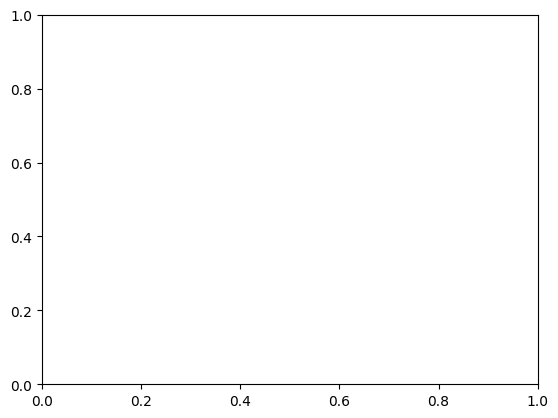

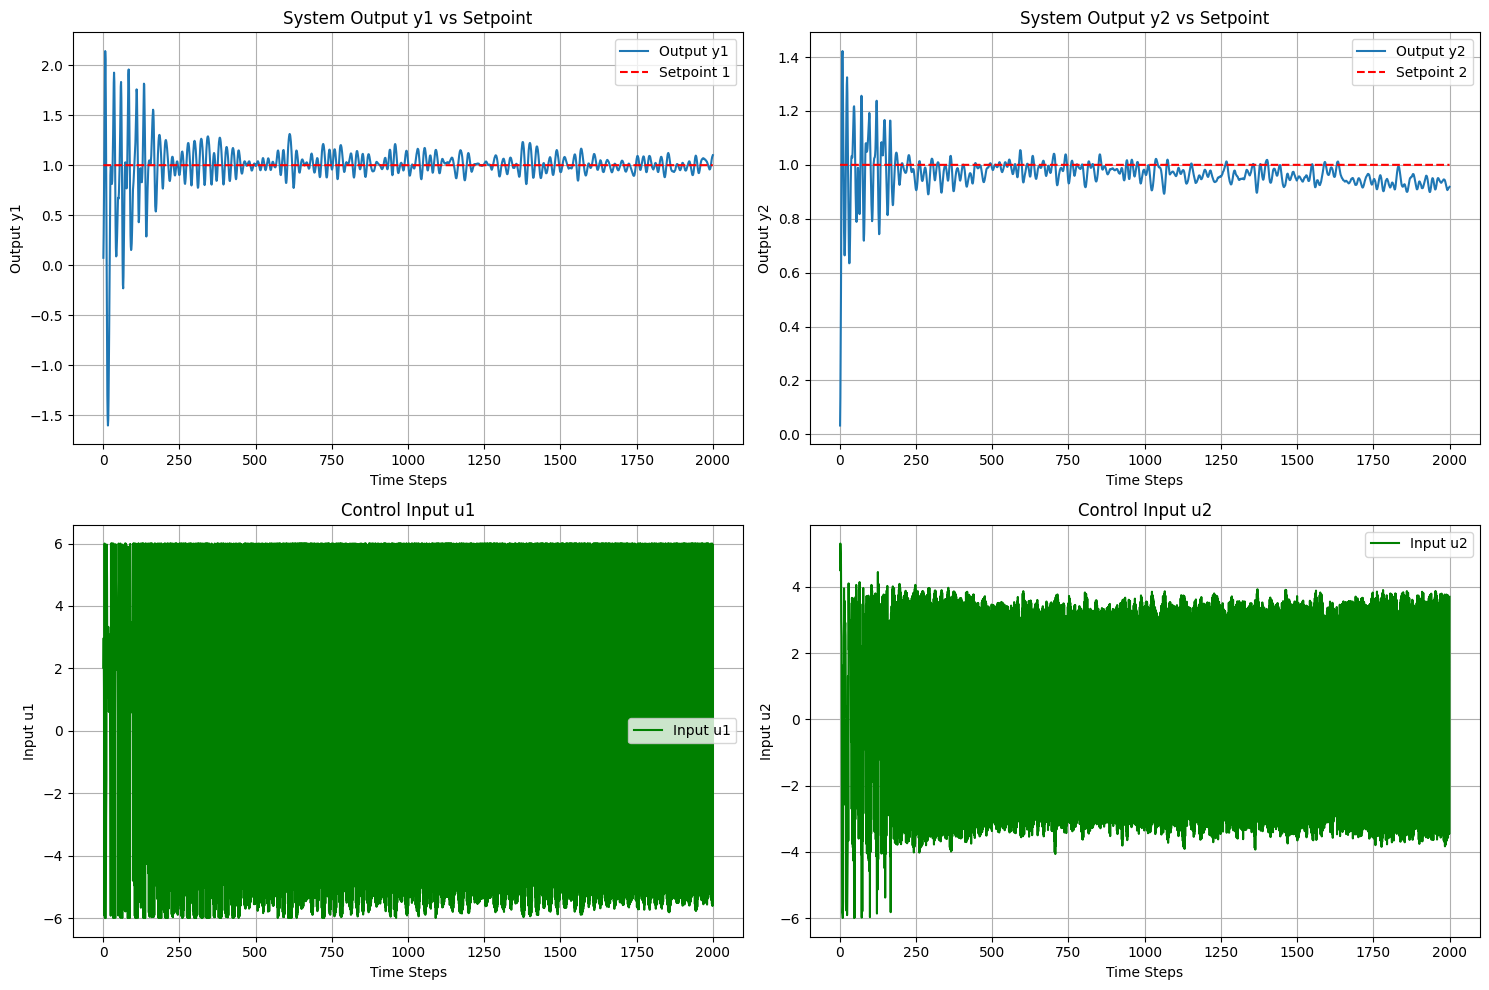

In [ ]:
from modelo_2x2 import TITOSystem
import numpy as np
import torch
from utils.MADDPGAgent import MADDPGAgent
from utils.buffer import BufferMADDPG
import matplotlib.pyplot as plt

def normalize_observation(obs):
    error = obs[0]
    y = obs[1]
    u_prev = obs[2]
    setpoint = obs[3]
    
    norm_error = error / NORM_ERROR
    norm_y = y / NORM_Y
    norm_u_prev = u_prev / NORM_U
    norm_setpoint = setpoint / NORM_SP
    
    normalized_obs = np.array([norm_error, norm_y, norm_u_prev, norm_setpoint], dtype=np.float32)
    return normalized_obs

state_dim = 4  # [error, y, u[-1], setpoint]
action_dim = 1
max_action = 6.0

n_episodes = 1000
max_steps = 2000
num_treino_per_step = 1

# Normalização
NORM_ERROR = 10.0
NORM_Y = 10.0
NORM_U = 6.0
NORM_SP = 6.0

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")
        
shared_buffer = BufferMADDPG(buffer_capacity=1000000, batch_size=2048,
                            state_dim=state_dim, action_dim=action_dim,
                            num_agents=2)

agent1 = MADDPGAgent(
    name='AGENTE UNO',
    state_dim=state_dim,
    action_dim=action_dim,
    max_action=max_action,
    buffer=shared_buffer,
    agent_id=0, 
    device=device,
    batch_size=2048,
    num_agents=2)

agent2 = MADDPGAgent(
    name='AGENTE DOS',
    state_dim=state_dim,   
    action_dim=action_dim,
    max_action=max_action,
    buffer=shared_buffer,
    agent_id=1,
    device=device,
    batch_size=2048,
    num_agents=2)

all_agents = [agent1, agent2]

# Ruído: aplicaremos decaimento POR PASSO (não por episódio)
initial_noise_std = 0.5
final_noise_std = 0.05
noise_decay_per_step = 0.99995  # ajuste fino — decaimento por passo
noise_std = initial_noise_std

#Plot de recompensas
total_reward_plot = []
figure, ax = plt.subplots()

# Ambiente
env = TITOSystem(K=np.array([[3,2],[2,5]]), wn1=1.0, wn2=0.5, zeta1=0.3, zeta2=0.4,
                 max_steps=max_steps, setpoint=[1.0, 1.0], render_mode="human")
graphics = False

for ep in range(n_episodes):
    obs, _ = env.reset()        # obs: array([obs1, obs2]) shape (2,4)
    obs1 = obs[0]
    obs2 = obs[1]
    total_reward1 = 0.0
    total_reward2 = 0.0
    
    for step in range(max_steps):
        # Normaliza observações
        obs1_norm = normalize_observation(obs1)
        obs2_norm = normalize_observation(obs2)
        obs_norm = np.array([obs1_norm, obs2_norm], dtype=np.float32)  # shape (2,4)

        # Torch tensors (batch dim 1)
        state_tensor1 = torch.FloatTensor(obs1_norm).unsqueeze(0).to(device)
        state_tensor2 = torch.FloatTensor(obs2_norm).unsqueeze(0).to(device)

        # Seleção de ação (cada agente retorna um escalar ou array (1,))
        a1 = agent1.select_action(state_tensor1, noise_std)
        a2 = agent2.select_action(state_tensor2, noise_std)

        # --- Normaliza o formato das ações para o ambiente e buffer ---
        # Se action for tensor, extrai scalar; se for array, extrai value
        def to_scalar(x):
            if isinstance(x, torch.Tensor):
                return float(x.detach().cpu().numpy().reshape(-1)[0])
            else:
                arr = np.asarray(x).reshape(-1)
                return float(arr[0])
        
        a1_s = to_scalar(a1)
        a2_s = to_scalar(a2)

        # Clipping de ação para limites do ambiente
        a1_s = float(np.clip(a1_s, -max_action, max_action))
        a2_s = float(np.clip(a2_s, -max_action, max_action))

        # Monta array para o env (lista de escalares) e para o buffer (2 x action_dim)
        env_actions = [a1_s, a2_s]
        buffer_actions = np.array([[a1_s], [a2_s]], dtype=np.float32)  # shape (2,1)

        # Step no ambiente
        next_obs, rewards, terminated, truncated, info = env.step(env_actions)
        done = bool(terminated or truncated)

        next_obs1 = next_obs[0]
        next_obs2 = next_obs[1]

        # Normaliza next_obs
        next_obs1_norm = normalize_observation(next_obs1)
        next_obs2_norm = normalize_observation(next_obs2)
        next_obs_norm = np.array([next_obs1_norm, next_obs2_norm], dtype=np.float32)

        # Rewards: garantir shape (num_agents, 1)
        r1 = float(rewards[0])
        r2 = float(rewards[1])
        buffer_rewards = np.array([[r1], [r2]], dtype=np.float32)  # shape (2,1)

        # Grava no buffer em formato consistente: (state[num_agents, s_dim], action[num_agents, a_dim], reward[num_agents,1], next_state)
        shared_buffer.record((obs_norm, buffer_actions, buffer_rewards, next_obs_norm))

        # Avança estados locais
        obs1 = next_obs1
        obs2 = next_obs2

        total_reward1 += r1
        total_reward2 += r2

        # Treino: só quando houver batch suficiente
        if shared_buffer.buffer_counter >= shared_buffer.batch_size:
            for _ in range(num_treino_per_step):
                agent1.train(all_agents)
                agent2.train(all_agents)

        # Decaimento do ruído POR PASSO
        noise_std = max(final_noise_std, noise_std * noise_decay_per_step)

        if done:
            break
    
    total_reward = total_reward1 + total_reward2
    total_reward_plot.append(total_reward)
    if graphics:
        ax.cla()                                    # limpa o conteúdo do gráfico
        ax.plot(range(len(total_reward_plot)), total_reward_plot)
                    # plota a lista atualizada
        ax.set_xlabel("Episódio")
        ax.set_ylabel("Recompensa Total")
        ax.set_title("Evolução da Recompensa por Episódio")
        ax.grid(True)
        plt.pause(0.01) 
    print(f"Episódio {ep+1}, Recompensa Total: {total_reward:.2f} | Agente 1: {total_reward1:.2f} | Agente 2: {total_reward2:.2f}")

    # Salva / render condicional (exemplo simples)
    if ep % 50 == 0:
        print(f"Ep {ep+1}: noise_std={noise_std:.4f}")

    # critério de salvar baseado em recompensa por agente (exemplo)
    if total_reward1 > 200 and total_reward2 > 200:
        try:
            env.render()
            agent1.save("maddpg_model_best1")
            agent2.save("maddpg_model_best2")
        except Exception as e:
            print("Render / Save falhou:", e)
        break

In [3]:
for ep in range(n_episodes):
    obs, _ = env.reset()        # obs: array([obs1, obs2]) shape (2,4)
    obs1 = obs[0]
    obs2 = obs[1]
    total_reward1 = 0.0
    total_reward2 = 0.0
    
    for step in range(max_steps):
        # Normaliza observações
        obs1_norm = normalize_observation(obs1)
        obs2_norm = normalize_observation(obs2)
        obs_norm = np.array([obs1_norm, obs2_norm], dtype=np.float32)  # shape (2,4)

        # Torch tensors (batch dim 1)
        state_tensor1 = torch.FloatTensor(obs1_norm).unsqueeze(0).to(device)
        state_tensor2 = torch.FloatTensor(obs2_norm).unsqueeze(0).to(device)

        # Seleção de ação (cada agente retorna um escalar ou array (1,))
        a1 = agent1.select_action(state_tensor1, noise_std)
        a2 = agent2.select_action(state_tensor2, noise_std)

        # --- Normaliza o formato das ações para o ambiente e buffer ---
        # Se action for tensor, extrai scalar; se for array, extrai value
        def to_scalar(x):
            if isinstance(x, torch.Tensor):
                return float(x.detach().cpu().numpy().reshape(-1)[0])
            else:
                arr = np.asarray(x).reshape(-1)
                return float(arr[0])
        
        a1_s = to_scalar(a1)
        a2_s = to_scalar(a2)

        # Clipping de ação para limites do ambiente
        a1_s = float(np.clip(a1_s, -max_action, max_action))
        a2_s = float(np.clip(a2_s, -max_action, max_action))

        # Monta array para o env (lista de escalares) e para o buffer (2 x action_dim)
        env_actions = [a1_s, a2_s]
        buffer_actions = np.array([[a1_s], [a2_s]], dtype=np.float32)  # shape (2,1)

        # Step no ambiente
        next_obs, rewards, terminated, truncated, info = env.step(env_actions)
        done = bool(terminated or truncated)

        next_obs1 = next_obs[0]
        next_obs2 = next_obs[1]

        # Normaliza next_obs
        next_obs1_norm = normalize_observation(next_obs1)
        next_obs2_norm = normalize_observation(next_obs2)
        next_obs_norm = np.array([next_obs1_norm, next_obs2_norm], dtype=np.float32)

        # Rewards: garantir shape (num_agents, 1)
        r1 = float(rewards[0])
        r2 = float(rewards[1])
        buffer_rewards = np.array([[r1], [r2]], dtype=np.float32)  # shape (2,1)

        # Grava no buffer em formato consistente: (state[num_agents, s_dim], action[num_agents, a_dim], reward[num_agents,1], next_state)
        shared_buffer.record((obs_norm, buffer_actions, buffer_rewards, next_obs_norm))

        # Avança estados locais
        obs1 = next_obs1
        obs2 = next_obs2

        total_reward1 += r1
        total_reward2 += r2

        # Treino: só quando houver batch suficiente
        if shared_buffer.buffer_counter >= shared_buffer.batch_size:
            for _ in range(num_treino_per_step):
                agent1.train(all_agents)
                agent2.train(all_agents)

        # Decaimento do ruído POR PASSO
        noise_std = max(final_noise_std, noise_std * noise_decay_per_step)

        if done:
            break
    
    total_reward = total_reward1 + total_reward2
    total_reward_plot.append(total_reward)
    if graphics:
        ax.cla()                                    # limpa o conteúdo do gráfico
        ax.plot(range(len(total_reward_plot)), total_reward_plot)
                    # plota a lista atualizada
        ax.set_xlabel("Episódio")
        ax.set_ylabel("Recompensa Total")
        ax.set_title("Evolução da Recompensa por Episódio")
        ax.grid(True)
        plt.pause(0.01) 
    print(f"Episódio {ep+1}, Recompensa Total: {total_reward:.2f} | Agente 1: {total_reward1:.2f} | Agente 2: {total_reward2:.2f}")

    # Salva / render condicional (exemplo simples)
    if ep % 50 == 0:
        print(f"Ep {ep+1}: noise_std={noise_std:.4f}")

    # critério de salvar baseado em recompensa por agente (exemplo)
    if total_reward1 > 200 and total_reward2 > 200:
        try:
            env.render()
            agent1.save("maddpg_model_best1")
            agent2.save("maddpg_model_best2")
        except Exception as e:
            print("Render / Save falhou:", e)
        break

Episódio 1, Recompensa Total: -53.79 | Agente 1: -304.08 | Agente 2: 250.29
Ep 1: noise_std=0.0500
Episódio 2, Recompensa Total: -1008.09 | Agente 1: -1058.08 | Agente 2: 49.98
Episódio 3, Recompensa Total: -473.72 | Agente 1: -526.44 | Agente 2: 52.72
Episódio 4, Recompensa Total: -219.89 | Agente 1: -249.39 | Agente 2: 29.50
Episódio 5, Recompensa Total: -641.90 | Agente 1: -643.50 | Agente 2: 1.60
Episódio 6, Recompensa Total: -8700.41 | Agente 1: -7797.52 | Agente 2: -902.89
Episódio 7, Recompensa Total: -5983.21 | Agente 1: -5270.22 | Agente 2: -712.98
Episódio 8, Recompensa Total: -2711.30 | Agente 1: -2470.12 | Agente 2: -241.18
Episódio 9, Recompensa Total: -2062.36 | Agente 1: -1914.39 | Agente 2: -147.97
Episódio 10, Recompensa Total: -1738.63 | Agente 1: -1667.55 | Agente 2: -71.08
Episódio 11, Recompensa Total: -2201.41 | Agente 1: -2066.24 | Agente 2: -135.17
Episódio 12, Recompensa Total: -2544.09 | Agente 1: -2381.92 | Agente 2: -162.17
Episódio 13, Recompensa Total: -76

KeyboardInterrupt: 